In [ ]:
pip install phe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.5 MB/s eta 0:00:00


[System] Using REAL Paillier Encryption on 1 cores.
[Setting] Pathological NON-IID data + Targeted Label Flip 1->7
[Audit] Stage-1-only FIP filtering enabled (Stage 2/3 removed; 50% high-rate FIP budget gate enabled).
[Data] Downloading/Loading MNIST (70k samples)...
[Data] Loaded MNIST from OpenML.
[Data] Train=55000, Public=5000, Test=10000
[Data] Distributing Pathological NON-IID (2 shards) to 10 clients...

 SEED: 123  (1/1)

 EXP: Attack Rate=10%  (1 malicious)
  -> Generating 64-bit Paillier Keys...
[System] Initializing FIP Verifier (Stage-1 bootstrap-only mode)...
  Malicious clients: ['C4']
  Targeted-eligible clients (has class 1): ['C1', 'C3', 'C4', 'C5', 'C7']

  [Ground Truth] Malicious: ['C4']

[FIP] Round 10 | median=0.110323 | MAD=0.029063 | dir_eps=0.000000
      Stage-1-only: accept if score > dir_eps; no Stage 2 magnitude filter; no Stage 3 history filter
      stage1_pass=9 | stage1_fail=1 | ref_mix=bootstrap:10
    Client       TAG    Type           Ref       Score

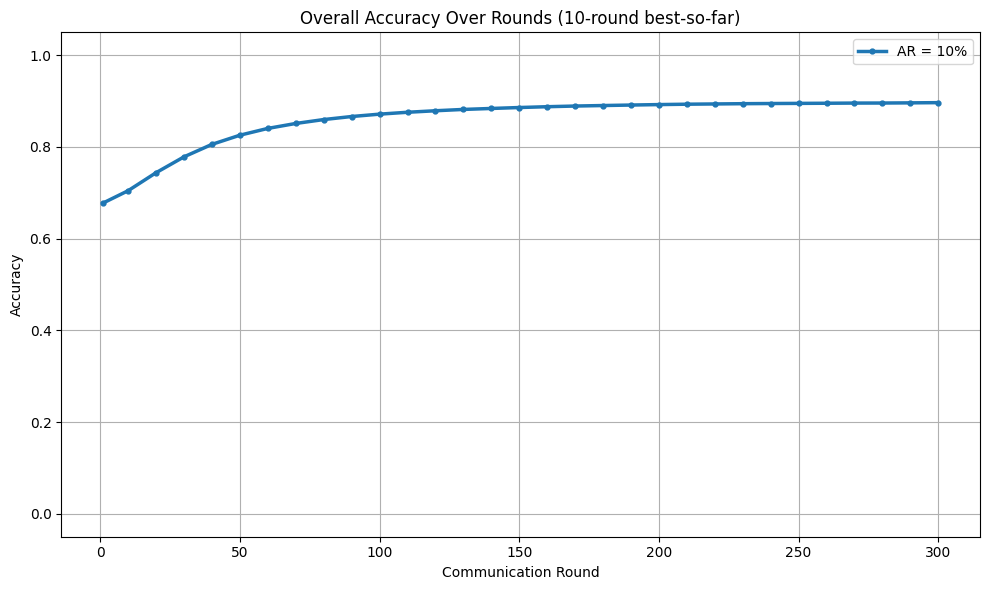

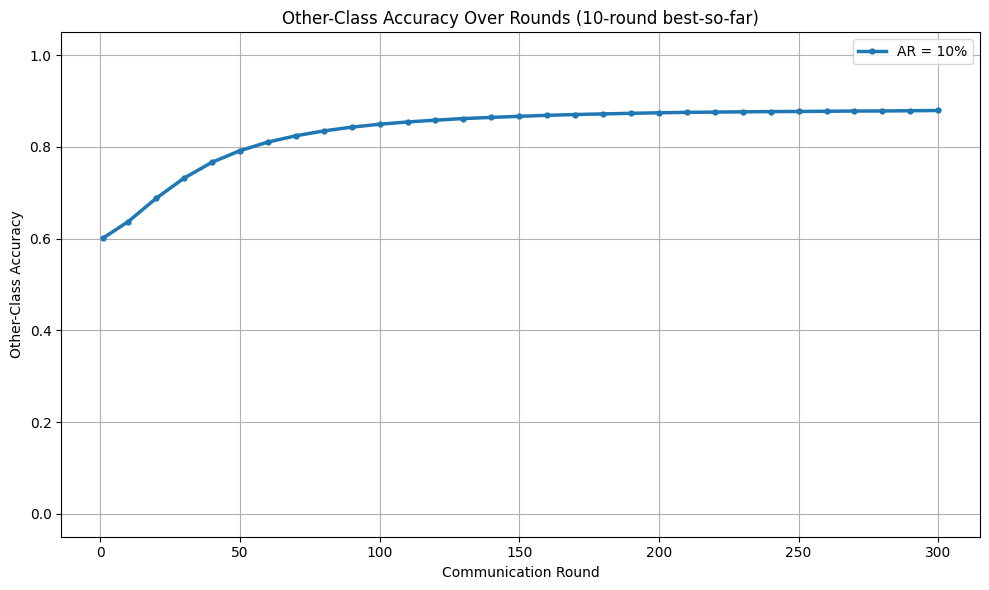

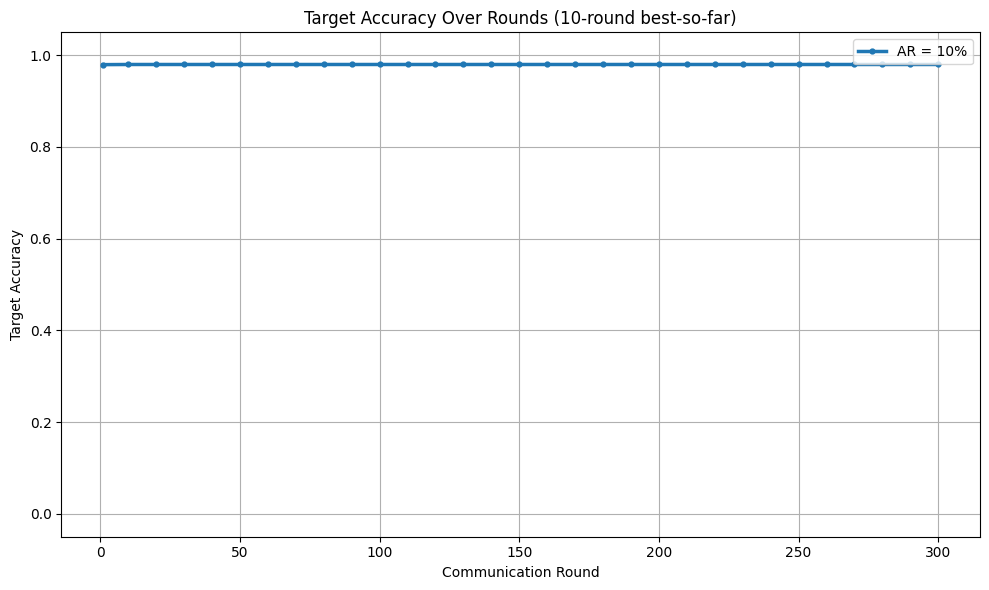


 FINAL RESULTS ACROSS ALL SEEDS

Attack Rate 10%:
  Overall Accuracy : 0.8975 ± 0.0000
  Target Accuracy  : 0.9751 ± 0.0000


In [ ]:
# Exported from non_iid_targeted_stage1_plotfix.ipynb

# In notebook cell: %pip install phe

# ============================================================
# Code Architecture Overview
# ============================================================
# This is the Stage-1 BOOTSTRAP-ONLY FIP-PPFL MNIST non-IID targeted-attack code.
# It is a test variant derived from the active-only notebook.
#
# Key bootstrap-only change:
#   - FIP score is computed only with the fixed bootstrap reference gradient.
#   - Active, stable, pub_* public-rescue, and clean/poison auxiliary
#     references are not used for client scoring or reference selection.
#   - The bootstrap reference is not updated after aggregation.
#
# Sections:
#   1. Global Setup and Multiprocessing Worker Helpers
#   2. Trusted Key Authority
#   3. Data Manager (non-IID partition; identical to untargeted variant)
#   4. FIP Verifier (bootstrap-reference Stage-1 malicious-client detector)
#   5. Client Manager (local training + targeted poisoning simulation)
#   6. Aggregation Server (secure aggregation + public calibration + evaluation)
#   7. Plotting and Result Utilities
#   8. Main Experiment Loop
# ============================================================
# ============================================================
# Slide-to-Code Map
# ============================================================
# - Slide 'Calculating FIP Score'       -> Section 4.8 + 4.10
# - Bootstrap reference initialization  -> Section 4.5
# - Bootstrap-only FIP scoring          -> Section 4.12
# - Final accept/reject decision        -> Section 4.17 Stage-1 decision loop
# - Reference update after aggregation  -> Section 4.18 no-op
# ============================================================

import os
import sys
import time
import numpy as np
import copy
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# BOOTSTRAP-ONLY TEST VARIANT
# ============================================================
# This file is derived from the working Stage-1 ACC/o_acc boost version.
# Change made for testing: FIP scoring uses only the fixed bootstrap reference gradient.
# Disabled in the audit decision:
#     active reference, stable reference, pub_* public rescue references,
#     and clean/poison auxiliary targeted references.
# Expected behavior: this file may produce different TPR/FPR/ACC than the
# active/multi-reference versions.
# ============================================================

# ============================================================
# 1. Global Setup and Multiprocessing Worker Helpers
# ============================================================
# This block imports libraries and auto-generates the worker module used by
# ProcessPoolExecutor. It keeps Jupyter/Colab multiprocessing stable.
worker_script = """
import math
import numpy as np
from phe import paillier

class MockCiphertext:
    def __init__(self, value): self.value = value
    def __add__(self, other): return MockCiphertext(self.value + other.value)
    def __mul__(self, other): return MockCiphertext(self.value * other)

class MockKey:
    def encrypt(self, value): return MockCiphertext(value)
    def decrypt(self, ciphertext): return ciphertext.value

def _safe_encrypt_int(pub_key, value, max_retries=16):
    if not hasattr(pub_key, 'nsquare'):
        return pub_key.encrypt(int(value))
    for _ in range(max_retries):
        enc = pub_key.encrypt(int(value))
        if math.gcd(int(enc.ciphertext(False)), int(pub_key.nsquare)) == 1:
            return enc
    raise ZeroDivisionError('Failed to sample an invertible Paillier ciphertext')

def _encrypt_chunk(args):
    pub_key, chunk = args
    return [_safe_encrypt_int(pub_key, x) for x in chunk]

def _decrypt_chunk(args):
    priv_key, chunk = args
    return [priv_key.decrypt(x) for x in chunk]

def _calc_score_worker(args):
    enc_chunk, ref_int_chunk = args
    if len(enc_chunk) == 0:
        return 0
    partial_sum = enc_chunk[0] * ref_int_chunk[0]
    for i in range(1, len(enc_chunk)):
        partial_sum = partial_sum + (enc_chunk[i] * ref_int_chunk[i])
    return partial_sum

def _train_client_worker(args):
    c_id, X, y, W_init, b_init, is_malicious, num_classes, input_dim, pub_key, scale, lr, batch, epochs = args

    W = W_init.copy()
    b = b_init.copy()
    prev_W = W.copy()
    prev_b = b.copy()
    y_train = y.copy()

    if is_malicious:
        # TARGETED LABEL FLIPPING ATTACK: class 1 -> class 7
        y_train[y_train == 1] = 7

    indices = np.arange(len(X))

    def softmax(z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    for _ in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, len(X), batch):
            end = start + batch
            idx = indices[start:end]
            if len(idx) == 0:
                continue

            X_b, y_b = X[idx], y_train[idx]
            scores = np.dot(X_b, W) + b
            probs = softmax(scores)
            y_oh = np.zeros((len(y_b), num_classes))
            y_oh[np.arange(len(y_b)), y_b] = 1
            error = probs - y_oh
            grad_W = np.dot(X_b.T, error) / len(X_b)
            grad_b = np.mean(error, axis=0)
            W -= lr * grad_W
            b -= lr * grad_b

    update_W = prev_W - W
    update_b = prev_b - b

    model_update = np.concatenate([update_W.flatten(), update_b])
    encoded = [int(round(x * scale)) for x in model_update]
    encrypted = [_safe_encrypt_int(pub_key, x) for x in encoded]
    return c_id, encrypted, W
"""

with open("fip_noniid_targeted_workers.py", "w") as f:
    f.write(worker_script)

from fip_noniid_targeted_workers import (
    _encrypt_chunk, _decrypt_chunk, _calc_score_worker,
    _train_client_worker, MockKey, MockCiphertext
)

# ============================================================
# ------------------------------------------------------------
# 1.1 Experiment Configuration
# ------------------------------------------------------------
# ============================================================
# Main hyperparameters: communication rounds, clients, local training settings,
# fixed-point scale for Paillier, and attack-rate list.
SEEDS = [123]
all_results = {}

N_ROUNDS = 300
N_CLIENTS = 10
BATCH_SIZE = 50
LEARNING_RATE = 0.01
LOCAL_EPOCHS = 1
USE_REAL_ENCRYPTION = True
FIXED_POINT_SCALE = 10000
ATTACK_RATES = [0.1, 0.2, 0.3, 0.5]
# For only 50% case, use: ATTACK_RATES = [0.5]

NUM_CORES = max(1, int(multiprocessing.cpu_count() * 0.90))

# ============================================================
# ------------------------------------------------------------
# 1.2 Plotting Options
# ------------------------------------------------------------
# ============================================================
# Raw metrics are saved exactly, while paper plots can use smooth/best-so-far
# curves for cleaner convergence visualization.
# Raw FL accuracy can naturally go slightly up/down because every round uses
# stochastic mini-batch training, non-IID clients, and a changing accepted-client set.
# For thesis/paper figures, keep the raw CSV but plot a smooth best-so-far curve.
PLOT_EVERY_N_ROUNDS = 10          # use the same 10-round reporting interval in figures
PLOT_MODE = "paper_monotonic"      # choices: "raw", "smooth", "paper_monotonic"
PLOT_EMA_ALPHA = 0.35             # used only for "smooth" / "paper_monotonic"
SAVE_RAW_PLOTS_TOO = True         # also saves raw curves for transparency

# ============================================================
# ------------------------------------------------------------
# 1.3 Accuracy Boost: trusted public calibration (optional)
# ------------------------------------------------------------
# ============================================================
# Purpose: improve Overall Accuracy and Other-label Accuracy without changing
# the Stage-1 FIP malicious-client detector. This uses only the trusted public
# bootstrap/calibration data already used for reference construction; no raw
# client data and no malicious-client labels are used.
#
# Why it helps: at 50% malicious rate, the detector correctly accepts only 5/10
# clients. Under pathological non-IID partitioning, those 5 honest clients may
# not cover all digit classes well, so the global model becomes weak on
# other-label classes. One small balanced public calibration step after each
# secure aggregation stabilizes the global classifier and usually improves ACC
# and o_acc while keeping TPR/FPR unchanged.
USE_SERVER_PUBLIC_CALIBRATION = True
PUBLIC_CALIBRATION_EVERY = 1        # calibrate after every round; set 5/10 for faster runs
PUBLIC_CALIBRATION_EPOCHS = 1
PUBLIC_CALIBRATION_BATCH_SIZE = 128
PUBLIC_CALIBRATION_LR = 0.003       # small LR so it boosts ACC/o_acc without overriding FL
PUBLIC_CALIBRATION_MAX_PER_CLASS = 250

# ============================================================
# ------------------------------------------------------------
# 1.4 Cryptographic Backend and Fixed-Point Encoder
# ------------------------------------------------------------
# ============================================================
# Select real Paillier encryption or mock encryption, and define fixed-point
# encode/decode utilities used for integer homomorphic arithmetic.
if USE_REAL_ENCRYPTION:
    from phe import paillier
    print(f"[System] Using REAL Paillier Encryption on {NUM_CORES} cores.")
else:
    print("[System] Using SIMULATED Encryption (Fast).")
print("[Setting] Pathological NON-IID data + Targeted Label Flip 1->7")
print("[Audit] Stage-1-only FIP filtering enabled (Stage 2/3 removed; 50% high-rate FIP budget gate enabled).")


# 1.4.1 Fixed-point encoder/decoder used before Paillier encryption.
class FixedPoint:
    """Encode/decode real-valued gradients for integer Paillier arithmetic."""

    def __init__(self, scale=FIXED_POINT_SCALE):
        self.scale = scale

    def encode(self, x):
        return int(round(x * self.scale))

    def decode(self, x):
        return float(x) / self.scale

    def decode_squared(self, x):
        return float(x) / (self.scale ** 2)

    def dec_vec(self, priv, enc_vec):
        if not USE_REAL_ENCRYPTION:
            return np.array([self.decode(priv.decrypt(c)) for c in enc_vec])
        chunk_size = max(1, len(enc_vec) // NUM_CORES + 1)
        chunks = [enc_vec[i:i + chunk_size] for i in range(0, len(enc_vec), chunk_size)]
        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            results = list(executor.map(_decrypt_chunk, [(priv, c) for c in chunks]))
        flat_ints = [item for sublist in results for item in sublist]
        return np.array([self.decode(x) for x in flat_ints])


# ============================================================
# 2. Trusted Key Authority
# ============================================================
# Purpose: generate Paillier keys, register users, and map anonymous TagIDs
# back to client IDs only for simulation/debug logging.
class TrustedKeyAuthority:
    """Generate Paillier keys, assign anonymous TagIDs, and expose key material in simulation."""

    # ------------------------------------------------------------
    # 2.1 Generate Paillier key pair and initialize registry.
    # ------------------------------------------------------------
    def __init__(self):
        if USE_REAL_ENCRYPTION:
            print("  -> Generating 64-bit Paillier Keys...")
            self.pub_key, self.priv_key = paillier.generate_paillier_keypair(n_length=64)
        else:
            self.pub_key, self.priv_key = MockKey(), MockKey()
        self.registry = {}

    # ------------------------------------------------------------
    # 2.2 Assign anonymous TagID to each client.
    # ------------------------------------------------------------
    def register_user(self, real_id):
        tag_id = f"TAG_{len(self.registry) + 1:03d}"
        self.registry[tag_id] = real_id
        return tag_id

    # ------------------------------------------------------------
    # 2.3 Share public/private keys inside this controlled simulation.
    # ------------------------------------------------------------
    def distribute_keys(self):
        return self.pub_key, self.priv_key

    # ------------------------------------------------------------
    # 2.4 Return TagID -> client ID mapping for logs only.
    # ------------------------------------------------------------
    def get_registry_snapshot(self):
        return self.registry.copy()


# ============================================================
# 3. Data Manager (non-IID partition; identical to untargeted variant)
# ============================================================
# Purpose: load MNIST, create public/bootstrap data, keep the test set, and
# split private client data using pathological non-IID shard partitioning.
class DataManager:
    """Load MNIST, create public/bootstrap data, test data, and pathological non-IID client splits."""

    # ------------------------------------------------------------
    # 3.1 Load MNIST and prepare public, private, and test splits.
    # ------------------------------------------------------------
    def __init__(self, n_clients):
        print("[Data] Downloading/Loading MNIST (70k samples)...")
        X, y = self._load_mnist()

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=10000, random_state=42, stratify=y)
        X_priv, X_pub, y_priv, y_pub = train_test_split(
            X_train, y_train, test_size=5000, random_state=42, stratify=y_train)

        self.test_data = (X_test, y_test)
        self.public_data = (X_pub, y_pub)
        self.public_calibration_data = self._make_balanced_public_calibration_data(
            X_pub, y_pub, max_per_class=PUBLIC_CALIBRATION_MAX_PER_CLASS
        )
        self.client_data = {}
        self.X_priv = X_priv
        self.y_priv = y_priv

        print(f"[Data] Train={len(X_priv)}, Public={len(X_pub)}, Test={len(X_test)}")
        print(f"[Data] Distributing Pathological NON-IID (2 shards) to {n_clients} clients...")
        self.create_non_iid_split(n_clients)

    # ------------------------------------------------------------
    # 3.2 Load MNIST from OpenML, with local cache fallback.
    # ------------------------------------------------------------
    def _load_mnist(self):
        try:
            X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
            X = X.astype(np.float32) / 255.0
            y = y.astype(int)
            print("[Data] Loaded MNIST from OpenML.")
            return X, y
        except Exception as e:
            print(f"[Data] OpenML load failed ({e}). Falling back to Keras MNIST...")

        try:
            from tensorflow.keras.datasets import mnist
        except Exception:
            from keras.datasets import mnist

        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        X = np.concatenate([x_train, x_test], axis=0).reshape(-1, 28 * 28).astype(np.float32) / 255.0
        y = np.concatenate([y_train, y_test], axis=0).astype(int)
        print("[Data] Loaded MNIST from Keras fallback.")
        return X, y

    # ------------------------------------------------------------
    # 3.3 Create pathological non-IID shard partition for clients.
    # ------------------------------------------------------------
    def create_non_iid_split(self, n_clients, shards_per_client=2):
        sorted_indices = np.argsort(self.y_priv)
        X_sorted = self.X_priv[sorted_indices]
        y_sorted = self.y_priv[sorted_indices]

        total_shards = n_clients * shards_per_client
        shard_size = len(X_sorted) // total_shards

        shards_X = [X_sorted[i * shard_size : (i + 1) * shard_size] for i in range(total_shards)]
        shards_y = [y_sorted[i * shard_size : (i + 1) * shard_size] for i in range(total_shards)]

        shard_indices = np.random.permutation(total_shards)
        for i in range(n_clients):
            idx1 = shard_indices[i * 2]
            idx2 = shard_indices[i * 2 + 1]
            self.client_data[i] = (
                np.concatenate([shards_X[idx1], shards_X[idx2]]),
                np.concatenate([shards_y[idx1], shards_y[idx2]])
            )

    # ------------------------------------------------------------
    # 3.4 Build a small class-balanced public set for optional server calibration.
    # ------------------------------------------------------------
    def _make_balanced_public_calibration_data(self, X, y, max_per_class=250):
        """Return a balanced trusted-public subset used only to improve ACC/o_acc.

        This is not a detector stage. It is a small server-side calibration set
        from the trusted public/bootstrap data. It helps when many malicious
        clients are rejected and the accepted non-IID clients do not represent
        all labels equally.
        """
        rng = np.random.default_rng(2026)
        selected = []
        for cls in range(10):
            cls_idx = np.where(y == cls)[0]
            if len(cls_idx) == 0:
                continue
            take = min(max_per_class, len(cls_idx))
            selected.extend(rng.choice(cls_idx, size=take, replace=False).tolist())
        selected = np.array(selected, dtype=int)
        rng.shuffle(selected)
        return X[selected], y[selected]

    # ------------------------------------------------------------
    # 3.5 Getter methods used by verifier/server/client manager.
    # ------------------------------------------------------------
    def get_public_data(self):
        return self.public_data

    def get_public_calibration_data(self):
        return self.public_calibration_data

    def get_test_data(self):
        return self.test_data

    def get_client_data(self, i):
        return self.client_data[i]

    def get_input_shape(self):
        return self.public_data[0].shape[1]


# ============================================================
# 4. FIP Verifier (Stage-1-only malicious-client detector)
# ============================================================
# Purpose: receive encrypted gradients, compute homomorphic FIP alignment scores,
# decrypt only scalar scores, and accept/reject clients using Stage 1 logic only.
# Stage 2 magnitude filtering and Stage 3 history/Z-score filtering are removed.

class FIPVerifier:
    """
    Bootstrap-only Stage-1 verifier for the FIP-PPFL architecture.

    Purpose:
    - Store encrypted client updates in an update table.
    - Homomorphically compute one Functional Inner Product (FIP) score per client.
    - Decrypt only the final scalar score, never the raw client gradient.
    - Use only the fixed bootstrap reference gradient for malicious-client filtering.
    - Forward only accepted encrypted updates to the server for aggregation.

    Removed intentionally:
    - Active/stable/public-rescue reference selection.
    - Clean/poison auxiliary targeted-reference scoring.
    - Stage 2 magnitude interval filtering.
    - Stage 3 history / Z-score consistency filtering.
    """

    # ------------------------------------------------------------
    # SLIDE STEP 1: Initialize verifier state and the bootstrap reference.
    # 4.1 Verifier initialization: keys, update table, bootstrap reference, and audit state.
    # ------------------------------------------------------------
    def __init__(self, key_authority, data_manager, input_dim, num_classes=10, attack_rate=0.0):
        """Initialize keys, the bootstrap reference gradient, audit state, and logging buffers."""
        print("[System] Initializing FIP Verifier (Stage-1 bootstrap-only mode)...")

        self.pub, self.priv = key_authority.distribute_keys()
        self.key_authority = key_authority
        self.attack_rate = attack_rate
        self.fp = FixedPoint()

        # The update table stores encrypted gradients indexed by anonymous TagID.
        self.update_table = {}

        # Momentum factor for updating the trusted reference after aggregation.
        self.alpha_ref = 0.8

        # Public/reference gradient used as plaintext FIP coefficients alpha.
        # BOOTSTRAP-ONLY variant: only the fixed bootstrap reference is used for FIP scoring.
        # No active, stable, pub_*, or targeted auxiliary references are scored.
        self.bootstrap_ref = self._initialize_bootstrap_reference(data_manager, input_dim, num_classes)
        self.targeted_refs = {}
        self.targeted_source_tags = set()

        # The bootstrap reference is the fixed trusted descent direction for this experiment.
        self.ref_directions = [self.bootstrap_ref.copy()]

        # Round-level state used by feedback() and logs.
        self.last_acceptance_ratio = 1.0
        self.empty_rounds = 0
        self.last_reference_source = "bootstrap"
        self.last_ref_usage = {}
        self.last_stage1_pass_count = 0
        self.last_stage1_fail_count = 0
        self.last_round_size = 0
        self.last_raw_median = 0.0
        self.last_positive_median = 0.0
        self.last_direction_eps = 0.0
        self.collapse_streak = 0

        # Optional detection-score buffers for later ROC-style analysis.
        self.roc_scores = []
        self.roc_labels = []

    # ------------------------------------------------------------
    # 4.2 Mark clients that contain source class 1 for the 1 -> 7 targeted attack.
    # ------------------------------------------------------------
    def set_targeted_source_tags(self, tag_ids):
        """Record which simulation clients contain the source class for the targeted attack."""
        self.targeted_source_tags = set(tag_ids)

    # ------------------------------------------------------------
    # 4.3 Reference-vector normalization utility.
    # ------------------------------------------------------------
    def _normalize_reference(self, ref_grad):
        """L2-normalize a reference vector so FIP scores behave like alignment scores."""
        norm = np.linalg.norm(ref_grad)
        if norm > 1e-12:
            return ref_grad / norm
        return ref_grad.copy()

    # ------------------------------------------------------------
    # 4.4 Build one trusted plaintext reference gradient from public data.
    # ------------------------------------------------------------
    def _compute_public_reference(self, X, y, num_classes):
        """
        Build a plaintext reference gradient from public/bootstrap data.

        This reference becomes alpha in the FIP equation:
            Dec( prod_k E(c_ik)^{alpha_k} ) = sum_k alpha_k c_ik.
        """
        if len(X) == 0:
            return None

        y_onehot = np.zeros((len(y), num_classes))
        y_onehot[np.arange(len(y)), y] = 1

        # At initialization, logits are zero, so softmax probability is uniform.
        probs = np.full((len(y), num_classes), 1.0 / num_classes)
        grad_W = np.dot(X.T, (probs - y_onehot)) / len(X)
        grad_b = np.mean(probs - y_onehot, axis=0)

        ref_grad = np.concatenate([grad_W.flatten(), grad_b])
        return self._normalize_reference(ref_grad)

    # ------------------------------------------------------------
    # 4.5 Initialize the fixed bootstrap reference.
    # ------------------------------------------------------------
    def _initialize_bootstrap_reference(self, data_manager, input_dim, num_classes):
        """Create the fixed bootstrap reference from trusted public data.

        In this bootstrap-only variant, this direction is the only reference used
        when computing client FIP scores. There is no bootstrap reference update,
        no stable backup reference, and no pub_* public-rescue reference in the
        audit decision.
        """
        X, y = data_manager.get_public_data()
        return self._compute_public_reference(X, y, num_classes)

    # ------------------------------------------------------------
    # 4.6 Auxiliary targeted references disabled in the bootstrap-only variant.
    # ------------------------------------------------------------
    def _disabled_targeted_references(self, data_manager, num_classes, source_class=1, target_class=7):
        """Return no auxiliary references; bootstrap-only scoring uses only alpha_bootstrap."""
        return {}

    # ------------------------------------------------------------
    # 4.7 Receive encrypted client updates into the verifier update table.
    # ------------------------------------------------------------
    def receive_update(self, tag_id, enc_gradient):
        """Receive one encrypted client update and store it until the audit step."""
        self.update_table[tag_id] = enc_gradient

    # ------------------------------------------------------------
    # SLIDE STEP 4: Compute encrypted FIP scores.
    # 4.8 Homomorphic FIP computation: prod_k E(c_ik)^(alpha_k).
    # ------------------------------------------------------------
    # ================= FIP SCORE CALCULATION =================
    # This function implements the equation shown in the FIP-score slide:
    #     prod_k E(c_ik)^{alpha_k} = E(sum_k alpha_k c_ik)
    # It performs encrypted scalar multiplication and homomorphic addition.
    # ==========================================================
    def _homomorphic_inner_product_parallel(self, enc_grad, ref_grad):
        """
        Compute encrypted FIP score using Paillier scalar multiplication and addition.

        For encrypted client vector E(c_i) and plaintext reference alpha:
            prod_k E(c_ik)^{alpha_k} = E(sum_k alpha_k c_ik)

        The verifier only decrypts the final scalar ciphertext in _score_clients_for_reference().
        """
        ref_ints = [self.fp.encode(x) for x in ref_grad]

        if not USE_REAL_ENCRYPTION:
            total = enc_grad[0] * ref_ints[0]
            for i in range(1, len(enc_grad)):
                total = total + (enc_grad[i] * ref_ints[i])
            return total

        chunk_size = max(1, len(enc_grad) // NUM_CORES + 1)
        enc_chunks = [enc_grad[i:i + chunk_size] for i in range(0, len(enc_grad), chunk_size)]
        ref_chunks = [ref_ints[i:i + chunk_size] for i in range(0, len(ref_ints), chunk_size)]

        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            partial_results = list(executor.map(_calc_score_worker, zip(enc_chunks, ref_chunks)))

        total = partial_results[0]
        for i in range(1, len(partial_results)):
            total = total + partial_results[i]
        return total

    # ------------------------------------------------------------
    # 4.9 Dynamic Stage-1 directional threshold epsilon.
    # ------------------------------------------------------------
    def _compute_direction_eps(self, round_num, noise_scale):
        """
        Dynamic Stage-1 directional threshold.

        A small negative tolerance is useful in pathological non-IID MNIST because some honest
        clients can have weak/near-zero alignment early in training. This reduces false positives
        and usually helps O_acc and overall ACC compared with strict score > 0 filtering.
        """
        if round_num < 20:
            return 0.0

        # Higher attack rates need stricter tolerance recovery after warmup.
        if self.attack_rate >= 0.5:
            if round_num < 100:
                return -min(0.15 * noise_scale, 0.03)
            if round_num < 250:
                return -min(0.10 * noise_scale, 0.01)
            return -min(0.05 * noise_scale, 0.005)

        if round_num < 100:
            return -min(0.10 * noise_scale, 5e-3)
        if round_num < 250:
            return -min(0.06 * noise_scale, 2e-3)
        return -min(0.03 * noise_scale, 5e-4)

    # ------------------------------------------------------------
    # 4.10 Compute/decrypt one scalar FIP score per client for one reference.
    # ------------------------------------------------------------
    # ================= DECRYPT FINAL SCALAR FIP SCORE =================
    # For one reference gradient, this function decrypts only one scalar
    # FIP score per client. Raw encrypted gradient coordinates remain hidden.
    # ================================================================
    def _score_clients_for_reference(self, tag_ids, ref_grad):
        """
        Calculate one plaintext FIP score per client for one reference vector.

        Internally:
        1. Homomorphically compute encrypted scalar FIP.
        2. Decrypt only that scalar.
        3. Decode fixed-point product by dividing by scale^2.
        4. Normalize by reference norm for consistent score comparison.
        """
        ref_norm = max(np.linalg.norm(ref_grad), 1e-12)
        scores_map = {}

        for tid in tag_ids:
            enc_grad = self.update_table[tid]
            enc_score = self._homomorphic_inner_product_parallel(enc_grad, ref_grad)
            raw_score_int = self.priv.decrypt(enc_score)
            scores_map[tid] = self.fp.decode_squared(raw_score_int) / ref_norm

        return scores_map

    # ------------------------------------------------------------
    # 4.11 Build bootstrap-only reference candidate.
    # ------------------------------------------------------------
    # ================= BOOTSTRAP-ONLY REFERENCE =================
    # Candidate reference: bootstrap only.
    # =========================================================
    def _build_reference_candidates(self):
        """Return the only reference used in this bootstrap-only experiment."""
        return [("bootstrap", self.ref_directions[0])]

    # ------------------------------------------------------------
    # SLIDE STEP 5: Bootstrap-only reference selection.
    # 4.12 Bootstrap-reference Stage-1 scoring.
    # ------------------------------------------------------------
    # ================= BOOTSTRAP-ONLY FIP SCORING =================
    # The original multi-reference function name is kept for compatibility with
    # the existing audit loop, but this variant never evaluates active or
    # pub_* references. Selected reference is always "bootstrap".
    # ===========================================================
    def _score_clients_multi_reference(self, tag_ids, round_num, direction_eps, noise_scale):
        """Score every client against the fixed bootstrap reference only."""
        scores_map = self._score_clients_for_reference(tag_ids, self.ref_directions[0])
        best_refs = {tid: "bootstrap" for tid in tag_ids}
        ref_usage = {"bootstrap": len(tag_ids)}
        self._last_per_ref_scores = {tid: {"bootstrap": scores_map.get(tid, -np.inf)} for tid in tag_ids}
        return scores_map, best_refs, ref_usage

    # ------------------------------------------------------------
    # 4.13 Targeted auxiliary reference detector disabled.
    # ------------------------------------------------------------
    # ================= BOOTSTRAP-ONLY DECISION =================
    # This notebook intentionally avoids clean/poisoned auxiliary references.
    # Filtering uses only the bootstrap-reference FIP score.
    # ========================================================
    def _detect_targeted_margin_stage1(self, tag_ids, scores_map, noise_scale, direction_eps, round_num):
        """Disabled in the bootstrap-only variant so no extra references are scored."""
        targeted_margin_reject = set()
        safe_source_tags = set()
        debug_info = None
        return targeted_margin_reject, safe_source_tags, debug_info

    # ------------------------------------------------------------
    # 4.14 Stage 1R: quorum rescue for honest near-threshold non-IID clients.
    # ------------------------------------------------------------
    def _apply_stage1_quorum_rescue(self, stage1_pass, stage1_fail, stage1_fail_reason, direction_eps, noise_scale):
        """
        Rescue near-threshold clients if Stage 1 becomes too strict in a non-IID round.

        This does not add Stage 2/3. It only prevents an unstable Stage-1 threshold from
        rejecting too many clients, which can hurt O_acc and overall ACC.
        """
        rescued = set()
        min_keep = int(np.ceil(0.50 * self.last_round_size))

        if len(stage1_pass) >= min_keep:
            return rescued

        # Only direction-failed clients are eligible; targeted-margin rejects remain rejected.
        near_slack = max(3.0 * noise_scale, 0.03)
        candidates = [
            (tid, score)
            for tid, score in stage1_fail.items()
            if stage1_fail_reason.get(tid) == "Direction" and score > (direction_eps - near_slack)
        ]
        candidates.sort(key=lambda kv: kv[1], reverse=True)

        for tid, score in candidates:
            if len(stage1_pass) >= min_keep:
                break
            stage1_pass[tid] = score
            stage1_fail.pop(tid, None)
            stage1_fail_reason.pop(tid, None)
            rescued.add(tid)

        return rescued

    # ------------------------------------------------------------
    # 4.15 Compute expected malicious-client budget from the attack rate.
    # ------------------------------------------------------------
    def _expected_reject_budget(self, num_clients):
        """
        Estimate how many clients may be rejected in this synthetic experiment.

        Why this is needed:
        - In the MNIST targeted-attack experiment, the attack rate is known by construction
          (10%, 30%, or 50%).
        - When the direction gate already reaches the expected malicious-client budget,
          rejecting extra direction-weak honest clients creates false positives under
          pathological non-IID data.
        - This is still Stage-1-only because the decision uses only FIP scores and the
          experiment's attack-rate budget; it does not use Stage 2 bounds or Stage 3 history.
        """
        if self.attack_rate <= 0:
            return 0
        return min(num_clients, max(1, int(np.ceil(self.attack_rate * num_clients))))

    # ------------------------------------------------------------
    # 4.16 Stage 1B: budget rescue to prevent extra false positives.
    # ------------------------------------------------------------
    def _apply_stage1_budget_rescue(self, stage1_pass, stage1_fail, stage1_fail_reason, scores_map):
        """
        Cap the number of rejected clients to the expected malicious-client budget.

        This reduces false positives at 10% and 30% attack rates when the basic
        direction gate rejects extra honest non-IID clients. Direction-based rejects are
        restored when the reject budget is already full.
        """
        rescued = set()
        reject_budget = self._expected_reject_budget(max(self.last_round_size, len(scores_map), 1))

        if reject_budget <= 0:
            # No malicious clients are expected in a clean run, so direction-only misses are
            # treated as benign non-IID drift instead of malicious evidence.
            direction_fails = [tid for tid, reason in stage1_fail_reason.items() if reason == "Direction"]
            for tid in direction_fails:
                stage1_pass[tid] = stage1_fail.pop(tid)
                stage1_fail_reason.pop(tid, None)
                rescued.add(tid)
            return rescued

        if len(stage1_fail) <= reject_budget:
            return rescued

        targeted_fails = [tid for tid, reason in stage1_fail_reason.items() if reason == "Targeted Margin"]
        direction_fails = [tid for tid, reason in stage1_fail_reason.items() if reason == "Direction"]

        # Active-only variant normally has no targeted-margin rejects; keep this guard for compatibility.
        remaining_direction_budget = max(0, reject_budget - len(targeted_fails))

        # If any direction rejects must remain, keep the lowest-score ones only. Higher
        # direction scores are more likely honest non-IID drift and are restored.
        keep_direction = set(
            tid for tid, _ in sorted(
                [(tid, scores_map.get(tid, -np.inf)) for tid in direction_fails],
                key=lambda kv: kv[1]
            )[:remaining_direction_budget]
        )

        for tid in direction_fails:
            if tid in keep_direction:
                continue
            stage1_pass[tid] = stage1_fail.pop(tid)
            stage1_fail_reason.pop(tid, None)
            rescued.add(tid)

        return rescued

    # ------------------------------------------------------------
    # SLIDE STEP 6: Filter clients using the final Stage-1 FIP score.
    # 4.17 Main Stage-1-only audit procedure executed once per FL round.
    # ------------------------------------------------------------
    # ================= FULL PER-ROUND STAGE-1 AUDIT =================
    # Main round pipeline:
    #   1) estimate noise from bootstrap-reference FIP scores,
    #   2) compute the final bootstrap-reference FIP score,
    #   3) apply the Stage-1 direction check,
    #   4) return only accepted encrypted updates for aggregation.
    # ================================================================
    def perform_fip_audit(self, round_num, mal_tags):
        """
        Run the Stage-1-only FIP audit for one communication round.

        Output:
        - dict containing only accepted encrypted updates.
        - rejected clients are treated as detected malicious for TPR/FPR logging.
        """
        tag_ids = list(self.update_table.keys())
        if not tag_ids:
            return {}

        self.last_round_size = len(tag_ids)

        # 1) Compute preliminary FIP score distribution to estimate noise/MAD.
        # Bootstrap-reference preliminary scores are used for sigma_noise/noise_scale.
        prelim_scores = self._score_clients_for_reference(tag_ids, self.ref_directions[0])
        prelim_vals = np.array(list(prelim_scores.values()), dtype=float)
        prelim_median = float(np.median(prelim_vals))
        prelim_mad = float(np.median(np.abs(prelim_vals - prelim_median)))
        noise_scale = max(prelim_mad, 1e-4)
        direction_eps = self._compute_direction_eps(round_num, noise_scale)

        # 2) Compute final Stage-1 FIP score using the bootstrap reference only.
        # The compatibility wrapper returns final_score for every client and selected_ref="bootstrap".
        scores_map, best_ref_map, ref_usage = self._score_clients_multi_reference(
            tag_ids, round_num, direction_eps, noise_scale
        )
        vals = np.array(list(scores_map.values()), dtype=float)
        raw_median = float(np.median(vals))
        raw_mad = float(np.median(np.abs(vals - raw_median)))
        noise_scale = max(raw_mad, 1e-4)
        direction_eps = self._compute_direction_eps(round_num, noise_scale)

        # 3) Targeted auxiliary-reference detection is disabled in this bootstrap-only variant.
        targeted_margin_reject, safe_source_tags, targeted_margin_debug = self._detect_targeted_margin_stage1(
            tag_ids, scores_map, noise_scale, direction_eps, round_num
        )

        # 4) Stage 1 decision: accept only clients with bootstrap-reference score > epsilon.
        stage1_pass = {}
        stage1_fail = {}
        stage1_fail_reason = {}

        # Final decision: bootstrap-reference final_score > eps_dir -> ACCEPT.
        # Otherwise -> REJECT as suspicious for aggregation/logging.
        for tid, score in scores_map.items():
            if tid in targeted_margin_reject:
                stage1_fail[tid] = score
                stage1_fail_reason[tid] = "Targeted Margin"
            elif score <= direction_eps:
                stage1_fail[tid] = score
                stage1_fail_reason[tid] = "Direction"
            else:
                stage1_pass[tid] = score

        # 5) Stage-1-only safety rescues to reduce false positives in difficult non-IID rounds.
        rescued_tags = self._apply_stage1_quorum_rescue(
            stage1_pass, stage1_fail, stage1_fail_reason, direction_eps, noise_scale
        )

        # Stage 1B: once the expected reject budget is reached, do
        # not let the simple direction gate add extra false positives. This helps
        # the 10%/30% runs where honest non-IID clients can sit near the threshold.
        budget_rescued_tags = self._apply_stage1_budget_rescue(
            stage1_pass, stage1_fail, stage1_fail_reason, scores_map
        )
        rescued_tags = set(rescued_tags) | set(budget_rescued_tags)

        accepted = set(stage1_pass.keys())
        registry = self.key_authority.get_registry_snapshot()
        verbose_round = ((round_num + 1) % 10 == 0)

        # 6) Save simple risk scores for optional ROC analysis.
        # Final decision: bootstrap-reference final_score > eps_dir -> ACCEPT.
        # Otherwise -> REJECT as suspicious for aggregation/logging.
        for tid, score in scores_map.items():
            risk = max(0.0, direction_eps - score)
            if tid in targeted_margin_reject:
                risk += 1.0
            self.roc_scores.append(risk)
            self.roc_labels.append(1 if tid in mal_tags else 0)

        # 7) Print Stage-1-only audit table every 10 rounds.
        if verbose_round:
            ref_mix = ", ".join(f"{name}:{count}" for name, count in sorted(ref_usage.items()))
            print(f"\n[FIP] Round {round_num + 1} | median={raw_median:.6f} | MAD={raw_mad:.6f} | dir_eps={direction_eps:.6f}")
            print(f"      Stage-1-only: accept if score > dir_eps; no Stage 2 magnitude filter; no Stage 3 history filter")
            print(f"      stage1_pass={len(stage1_pass)} | stage1_fail={len(stage1_fail)} | ref_mix={ref_mix}")

            if targeted_margin_debug is not None and targeted_margin_reject:
                gap, threshold, delta = targeted_margin_debug
                print(
                    f"      [Aux disabled] Targeted-margin set contains {len(targeted_margin_reject)} clients "
                    f"(gap={gap:.6f}, thresh={threshold:.6f}, delta={delta:.6f})"
                )

            if rescued_tags:
                print(f"      [Stage 1R/1B] Non-IID/budget rescue restored {len(rescued_tags)} clients")

            print(f"  {'Client':>8}  {'TAG':>8}  {'Type':>6}  {'Ref':>12}  {'Score':>10}  Result")
            print(f"  {'-' * 86}")

            for tid, score in scores_map.items():
                client_id = registry.get(tid, "Unknown")
                client_type = "MAL" if tid in mal_tags else "HON"
                best_ref_name = best_ref_map.get(tid, "bootstrap")

                if tid in accepted:
                    result = "ACCEPT"
                    if tid in rescued_tags:
                        result += " (Stage 1R/1B)"
                else:
                    reason = stage1_fail_reason.get(tid, "Direction")
                    if reason == "Targeted Margin":
                        result = "REJECT (auxiliary targeted margin)"
                    else:
                        result = "REJECT (Stage 1: score <= dir_eps)"

                print(f"  {client_id:>8}  {tid:>8}  {client_type:>6}  {best_ref_name:>12}  {score:>10.4f}  {result}")

            print(f"  -> Accepted {len(accepted)}/{len(tag_ids)} clients")

        # 8) Update round state and clear the update table.
        acceptance_ratio = len(accepted) / len(tag_ids) if tag_ids else 1.0
        self.last_acceptance_ratio = acceptance_ratio
        self.empty_rounds = 0 if accepted else (self.empty_rounds + 1)
        self.last_reference_source = max(ref_usage, key=ref_usage.get) if ref_usage else "bootstrap"
        self.last_ref_usage = ref_usage
        self.last_stage1_pass_count = len(stage1_pass)
        self.last_stage1_fail_count = len(stage1_fail)
        self.last_raw_median = raw_median
        positive_scores = np.array(list(stage1_pass.values()), dtype=float) if stage1_pass else np.array([], dtype=float)
        self.last_positive_median = float(np.median(positive_scores)) if len(positive_scores) else direction_eps
        self.last_direction_eps = direction_eps

        survivor_ratio = len(stage1_pass) / max(len(tag_ids), 1)
        collapse_detected = (survivor_ratio < 0.5 and raw_median <= direction_eps)
        self.collapse_streak = (self.collapse_streak + 1) if collapse_detected else 0

        if len(accepted) == 0 and verbose_round:
            print("  [Safety] No client accepted this round; aggregation skipped.")

        snapshot = self.update_table.copy()
        self.update_table = {}

        return {tid: {"count": 1, "enc_data": snapshot[tid]} for tid in accepted}

    # ------------------------------------------------------------
    # SLIDE STEP 8: Keep the bootstrap reference fixed after aggregation.
    # 4.18 Feedback is intentionally disabled for bootstrap-only testing.
    # ------------------------------------------------------------
    # ================= FIXED BOOTSTRAP REFERENCE =================
    # The bootstrap-only baseline must not update or replace its reference.
    # This lets us compare against variants that use active or public references.
    # ============================================================
    def feedback(self, global_grad):
        """No-op: bootstrap-only scoring keeps the initial bootstrap reference fixed."""
        return



# ============================================================
# SLIDE STEP 2: Local training orchestration happens in ClientManager and _train_client_worker.
# 5. Client Manager (local training + targeted poisoning simulation)
# ============================================================
# Purpose: initialize clients, inject targeted label-flip behavior for malicious
# clients, and run one encrypted local-training job per client per round.
class ClientManager:
    """Create client configs and run one local encrypted-training job per client per round."""

    # ------------------------------------------------------------
    # 5.1 Store references to auth/data manager and initialize local model states.
    # ------------------------------------------------------------
    def __init__(self, auth, dm, dim):
        self.auth = auth
        self.dm = dm
        self.dim = dim
        self.clients_state_W = {}
        self.clients_state_b = {}
        self.client_configs = []

    # ------------------------------------------------------------
    # 5.2 Register clients and choose malicious clients for the current experiment.
    # ------------------------------------------------------------
    def init_clients(self, n_clients, num_malicious):
        self.client_configs = []
        all_indices = list(range(n_clients))
        malicious_indices = np.random.choice(all_indices, num_malicious, replace=False)

        class_1_mask = self.dm.y_priv == 1
        X_class_1 = self.dm.X_priv[class_1_mask]
        y_class_1 = self.dm.y_priv[class_1_mask]

        for i in range(n_clients):
            is_mal = (i in malicious_indices)
            c_id = f"C{i}"
            X, y = self.dm.get_client_data(i)

            if is_mal and len(X_class_1) > 0:
                half = max(1, len(y) // 2)
                idx = np.random.choice(len(X_class_1), min(half, len(X_class_1)), replace=False)
                X_mod = np.copy(X)
                y_mod = np.copy(y)
                X_mod[:len(idx)] = X_class_1[idx]
                y_mod[:len(idx)] = y_class_1[idx]
                X = X_mod
                y = y_mod

            has_source_class = bool(np.any(y == 1))

            self.client_configs.append({
                'id': c_id,
                'X': X,
                'y': y,
                'mal': is_mal,
                'source_present': has_source_class,
                'reg_tag': self.auth.register_user(c_id)
            })
            self.clients_state_W[c_id] = np.zeros((self.dim, 10))
            self.clients_state_b[c_id] = np.zeros(10)

        mal_ids = [f"C{i}" for i in malicious_indices]
        targeted_ids = sorted([cfg['id'] for cfg in self.client_configs if cfg['source_present']])
        print(f"  Malicious clients: {sorted(mal_ids)}")
        print(f"  Targeted-eligible clients (has class 1): {targeted_ids}")

    # ------------------------------------------------------------
    # SLIDE STEPS 2-3: run local training, then return encrypted client updates.
    # 5.3 Run local training for all clients and return encrypted updates.
    # ------------------------------------------------------------
    def run_training_round(self, global_W, global_b):
        jobs = []
        pub, _ = self.auth.distribute_keys()
        for cfg in self.client_configs:
            self.clients_state_W[cfg['id']] = copy.deepcopy(global_W)
            self.clients_state_b[cfg['id']] = copy.deepcopy(global_b)
            args = (
                cfg['id'], cfg['X'], cfg['y'],
                self.clients_state_W[cfg['id']], self.clients_state_b[cfg['id']],
                cfg['mal'], 10, self.dim, pub, FIXED_POINT_SCALE,
                LEARNING_RATE, BATCH_SIZE, LOCAL_EPOCHS
            )
            jobs.append(args)

        with ProcessPoolExecutor(max_workers=NUM_CORES) as executor:
            results = list(executor.map(_train_client_worker, jobs))
        return results


# ============================================================
# SLIDE STEP 7: Secure aggregation of accepted encrypted updates happens in Server.aggregate().
# 6. Aggregation Server (secure aggregation + evaluation)
# ============================================================
# Purpose: aggregate accepted encrypted updates, decrypt only the aggregate,
# optionally calibrate on trusted public data, and compute ACC / target ACC / other-class ACC.
class Server:
    """Aggregate accepted encrypted client updates and evaluate the global MNIST model."""

    # ------------------------------------------------------------
    # 6.1 Initialize the global logistic-regression model.
    # ------------------------------------------------------------
    def __init__(self, input_dim, num_classes=10):
        self.W = np.zeros((input_dim, num_classes))
        self.b = np.zeros(num_classes)
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.fp = FixedPoint()

    # ------------------------------------------------------------
    # SLIDE STEP 7: Aggregate accepted encrypted updates and decrypt only the aggregate.
    # 6.2 Aggregate accepted encrypted updates and decrypt only the aggregate.
    # ------------------------------------------------------------
    # ================= SECURE AGGREGATION OF ACCEPTED CLIENTS =================
    # The server aggregates only encrypted updates that passed Stage-1 FIP audit.
    # ========================================================================
    def aggregate(self, packet, auth_priv):
        if not packet:
            return None
        first = list(packet.keys())[0]
        agg_enc = packet[first]['enc_data'][:]
        count = 1
        keys = list(packet.keys())
        for i in range(1, len(keys)):
            data = packet[keys[i]]['enc_data']
            for j in range(len(agg_enc)):
                agg_enc[j] = agg_enc[j] + data[j]
            count += 1

        flat_agg = self.fp.dec_vec(auth_priv, agg_enc)
        avg_update = flat_agg / count
        w_size = self.input_dim * self.num_classes
        update_W = avg_update[:w_size].reshape(self.input_dim, self.num_classes)
        update_b = avg_update[w_size:]
        self.W -= update_W
        self.b -= update_b
        return avg_update

    # ------------------------------------------------------------
    # 6.3 Optional trusted-public calibration step to improve ACC and o_acc.
    # ------------------------------------------------------------
    # ================= OPTIONAL PUBLIC CALIBRATION =================
    # Accuracy/o_acc boost after aggregation. This is NOT a new detection stage.
    # =============================================================
    def calibrate_on_public_data(self, X_pub, y_pub, lr=PUBLIC_CALIBRATION_LR,
                                 batch_size=PUBLIC_CALIBRATION_BATCH_SIZE,
                                 epochs=PUBLIC_CALIBRATION_EPOCHS):
        """Run a tiny supervised update on trusted public/bootstrap data.

        This does not use client raw data and does not change the Stage-1 FIP
        detector. It only fine-tunes the server model after aggregation so that
        classes missing from the accepted non-IID client set are still learned.
        """
        if X_pub is None or y_pub is None or len(X_pub) == 0:
            return

        def softmax(z):
            exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
            return exp_z / exp_z.sum(axis=1, keepdims=True)

        indices = np.arange(len(X_pub))
        for _ in range(epochs):
            np.random.shuffle(indices)
            for start in range(0, len(indices), batch_size):
                idx = indices[start:start + batch_size]
                if len(idx) == 0:
                    continue
                X_b = X_pub[idx]
                y_b = y_pub[idx]
                scores = np.dot(X_b, self.W) + self.b
                probs = softmax(scores)
                y_oh = np.zeros((len(y_b), self.num_classes))
                y_oh[np.arange(len(y_b)), y_b] = 1
                error = probs - y_oh
                grad_W = np.dot(X_b.T, error) / len(X_b)
                grad_b = np.mean(error, axis=0)
                self.W -= lr * grad_W
                self.b -= lr * grad_b

    # ------------------------------------------------------------
    # 6.4 Evaluate target-class, other-class, and overall accuracy.
    # ------------------------------------------------------------
    def evaluate_detailed(self, X_test, y_test):
        scores = np.dot(X_test, self.W) + self.b
        preds = np.argmax(scores, axis=1)
        acc = accuracy_score(y_test, preds)
        t_mask = y_test == 1
        t_acc = accuracy_score(y_test[t_mask], preds[t_mask]) if any(t_mask) else 0.0
        o_mask = (y_test != 1) & (y_test != 7)
        o_acc = accuracy_score(y_test[o_mask], preds[o_mask]) if any(o_mask) else 0.0
        return t_acc, o_acc, acc


# ============================================================
# 7. Plotting and Result Utilities
# ============================================================
# Purpose: prepare paper-ready convergence plots while preserving raw per-round
# CSV results for debugging and transparent reporting.

def _ema_smooth(values, alpha=PLOT_EMA_ALPHA):
    """Return an exponential moving average with the same length as values."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    out = np.zeros_like(values, dtype=float)
    out[0] = values[0]
    for i in range(1, len(values)):
        out[i] = alpha * values[i] + (1.0 - alpha) * out[i - 1]
    return out


# ------------------------------------------------------------
# 7.1 Convert raw per-round metrics into plotting curves.
# ------------------------------------------------------------
def _prepare_plot_curve(raw_metric, rounds, mode=PLOT_MODE, every_n=PLOT_EVERY_N_ROUNDS):
    """
    Prepare curves for visualization without changing the saved raw results.

    Modes:
    - raw             : plot every round exactly as measured.
    - smooth          : plot 10-round sampled EMA curve.
    - paper_monotonic : plot 10-round sampled EMA best-so-far curve.

    The paper_monotonic curve is useful for presentation figures where the desired
    message is convergence trend. It must be interpreted as best-so-far visualization;
    raw per-round metrics remain in the CSV file.
    """
    raw_metric = np.asarray(raw_metric, dtype=float)
    rounds = np.asarray(rounds, dtype=int)

    if mode == "raw":
        return rounds, raw_metric

    step = max(1, int(every_n))
    sample_idx = np.arange(step - 1, len(raw_metric), step)
    if len(sample_idx) == 0 or sample_idx[0] != 0:
        sample_idx = np.r_[0, sample_idx]
    sample_idx = np.unique(sample_idx)

    sampled_rounds = rounds[sample_idx]
    sampled_values = raw_metric[sample_idx]
    smoothed_values = _ema_smooth(sampled_values)

    if mode == "paper_monotonic":
        smoothed_values = np.maximum.accumulate(smoothed_values)

    return sampled_rounds, smoothed_values


# ------------------------------------------------------------
# 7.2 Generate final ACC / O_acc / T_acc plots.
# ------------------------------------------------------------
def generate_accuracy_metric_plots(history, attack_rates, n_rounds):
    """Generate smooth paper figures and optional raw plots for ACC, O_acc, and T_acc."""
    styles = ['-', '--', '-.', ':']
    rounds = np.arange(1, n_rounds + 1)
    plot_specs = [
        ('acc', 'Overall Accuracy Over Rounds', 'Accuracy', 'codex_noniid_targeted_overall_accuracy.png'),
        ('o_acc', 'Other-Class Accuracy Over Rounds', 'Other-Class Accuracy', 'codex_noniid_targeted_other_accuracy.png'),
        ('t_acc', 'Target Accuracy Over Rounds', 'Target Accuracy', 'codex_noniid_targeted_target_accuracy.png'),
    ]

    # 1) Paper/presentation plots: smooth convergence trend.
    for metric_key, title, ylabel, filename in plot_specs:
        plt.figure(figsize=(10, 6))
        for i, ar in enumerate(attack_rates):
            mean_metric = np.mean(history[ar][metric_key], axis=0)
            plot_rounds, plot_metric = _prepare_plot_curve(mean_metric, rounds, mode=PLOT_MODE)
            plt.plot(
                plot_rounds,
                plot_metric,
                linestyle=styles[i % len(styles)],
                linewidth=2.5,
                marker='o' if PLOT_MODE != "raw" else None,
                markersize=3.5,
                label=f"AR = {ar * 100:.0f}%"
            )
        suffix = ""
        if PLOT_MODE == "smooth":
            suffix = " (10-round EMA)"
        elif PLOT_MODE == "paper_monotonic":
            suffix = " (10-round best-so-far)"
        plt.title(title + suffix)
        plt.xlabel('Communication Round')
        plt.ylabel(ylabel)
        plt.ylim([-0.05, 1.05])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
        plt.show()
        plt.close()

    # 2) Raw plots: exact measured values, useful for debugging and honest reporting.
    if SAVE_RAW_PLOTS_TOO:
        for metric_key, title, ylabel, filename in plot_specs:
            raw_filename = filename.replace('.png', '_raw.png')
            plt.figure(figsize=(10, 6))
            for i, ar in enumerate(attack_rates):
                mean_metric = np.mean(history[ar][metric_key], axis=0)
                plt.plot(
                    rounds,
                    mean_metric,
                    linestyle=styles[i % len(styles)],
                    linewidth=1.6,
                    alpha=0.85,
                    label=f"AR = {ar * 100:.0f}%"
                )
            plt.title(title + ' (raw per-round)')
            plt.xlabel('Communication Round')
            plt.ylabel(ylabel)
            plt.ylim([-0.05, 1.05])
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(raw_filename, dpi=300)
            plt.close()



# ============================================================
# SLIDE STEPS 1-8: Main loop wires together initialization, training, audit, aggregation, and reference update.
# 8. Main Experiment Loop
# ============================================================
# Purpose: run all seeds and attack rates, collect TPR/FPR/accuracy metrics,
# save CSV files, and generate final plots.
# ------------------------------------------------------------
# 8.1 Entry point for running the full MNIST non-IID targeted experiment.
# ------------------------------------------------------------
if __name__ == '__main__':
    multiprocessing.set_start_method('spawn', force=True)

    history = {
        ar: {
            'acc': np.zeros((len(SEEDS), N_ROUNDS)),
            't_acc': np.zeros((len(SEEDS), N_ROUNDS)),
            'o_acc': np.zeros((len(SEEDS), N_ROUNDS)),
            'tpr': np.zeros((len(SEEDS), N_ROUNDS)),
            'fpr': np.zeros((len(SEEDS), N_ROUNDS))
        }
        for ar in ATTACK_RATES
    }
    roc_data = {ar: {'y_true': [], 'y_score': []} for ar in ATTACK_RATES}
    all_round_results = []

    np.random.seed(42)
    dm = DataManager(N_CLIENTS)
    dim = dm.get_input_shape()

    for seed_idx, seed in enumerate(SEEDS):
        print(f"\n{'=' * 60}")
        print(f" SEED: {seed}  ({seed_idx + 1}/{len(SEEDS)})")
        print(f"{'=' * 60}")

        np.random.seed(seed)

        for attack_rate in ATTACK_RATES:
            num_malicious = int(N_CLIENTS * attack_rate)
            print(f"\n{'=' * 60}")
            print(f" EXP: Attack Rate={attack_rate * 100:.0f}%  ({num_malicious} malicious)")
            print(f"{'=' * 60}")

            auth = TrustedKeyAuthority()
            verifier = FIPVerifier(auth, dm, dim, 10, attack_rate=attack_rate)
            server = Server(dim, 10)
            client_mgr = ClientManager(auth, dm, dim)
            client_mgr.init_clients(N_CLIENTS, num_malicious)

            verifier.set_targeted_source_tags({
                c['reg_tag'] for c in client_mgr.client_configs if c['source_present']
            })

            X_test, y_test = dm.get_test_data()
            X_public_calib, y_public_calib = dm.get_public_calibration_data()

            mal_tags = {c['reg_tag'] for c in client_mgr.client_configs if c['mal']}
            honest_tags = {c['reg_tag'] for c in client_mgr.client_configs if not c['mal']}
            actual_mal_ids = sorted([auth.registry[t] for t in mal_tags])
            print(f"\n  [Ground Truth] Malicious: {actual_mal_ids}")

            for r in range(N_ROUNDS):
                start_time = time.time()

                results = client_mgr.run_training_round(server.W, server.b)
                for res in results:
                    c_id, enc_grad, _ = res
                    tag = [c['reg_tag'] for c in client_mgr.client_configs if c['id'] == c_id][0]
                    verifier.receive_update(tag, enc_grad)

                packet = verifier.perform_fip_audit(round_num=r, mal_tags=mal_tags)

                if packet:
                    grad = server.aggregate(packet, auth.priv_key)
                    if grad is not None:
                        verifier.feedback(grad)

                # Optional ACC/o_acc boost: after secure aggregation, fine-tune the
                # server model with a tiny class-balanced trusted-public step.
                # Detection metrics are still computed from Stage-1 FIP decisions only.
                if (USE_SERVER_PUBLIC_CALIBRATION
                        and ((r + 1) % PUBLIC_CALIBRATION_EVERY == 0)):
                    server.calibrate_on_public_data(X_public_calib, y_public_calib)

                t_acc, o_acc, acc = server.evaluate_detailed(X_test, y_test)
                history[attack_rate]['acc'][seed_idx, r] = acc
                history[attack_rate]['t_acc'][seed_idx, r] = t_acc
                history[attack_rate]['o_acc'][seed_idx, r] = o_acc

                accepted_tags = set(packet.keys()) if packet else set()
                rejected_tags = mal_tags.union(honest_tags) - accepted_tags

                TP = len(rejected_tags & mal_tags)
                FP = len(rejected_tags & honest_tags)
                tpr = TP / len(mal_tags) if len(mal_tags) > 0 else 1.0
                fpr = FP / len(honest_tags) if len(honest_tags) > 0 else 0.0

                history[attack_rate]['tpr'][seed_idx, r] = tpr
                history[attack_rate]['fpr'][seed_idx, r] = fpr

                TN = len(accepted_tags & honest_tags)
                all_round_results.append({
                    'Seed': seed,
                    'Attack_Rate': attack_rate,
                    'Round': r + 1,
                    'Acc': acc,
                    'Target_Acc': t_acc,
                    'Other_Acc': o_acc,
                    'TPR': tpr,
                    'FPR': fpr,
                    'Actual_Malicious_Detected': f"{TP}/{len(mal_tags)}",
                    'Actual_Honest_Detected': f"{TN}/{len(honest_tags)}",
                })

                dt = time.time() - start_time

                if (r + 1) % 10 == 0:
                    detected_ids = sorted([auth.registry[t] for t in rejected_tags])
                    accepted_ids = sorted([auth.registry[t] for t in accepted_tags])
                    true_positive_ids = sorted([auth.registry[t] for t in (rejected_tags & mal_tags)])
                    false_positive_ids = sorted([auth.registry[t] for t in (rejected_tags & honest_tags)])
                    print(
                        f"\n  Round {r + 1:>3}: ACC={acc:.4f} | t_acc={t_acc:.4f} | "
                        f"o_acc={o_acc:.4f} | TPR={tpr:.2f} | FPR={fpr:.2f}"
                    )
                    print(f"    Actual Malicious   : {actual_mal_ids}")
                    print(f"    Detected Malicious : {detected_ids}")
                    print(f"    True Positives     : {true_positive_ids}")
                    print(f"    False Positives    : {false_positive_ids}")
                    print(f"    Accepted Clients   : {accepted_ids}")
                    print(f"    Rejected Clients   : {detected_ids}")
                    print(f"    Round Time         : {dt:.2f}s")

            roc_data[attack_rate]['y_true'].extend(verifier.roc_labels)
            roc_data[attack_rate]['y_score'].extend(verifier.roc_scores)

    df_all_rounds = pd.DataFrame(all_round_results)
    df_all_rounds.to_csv('codex_noniid_targeted_all_round_results.csv', index=False)
    print(f"[CSV] Saved {len(df_all_rounds)} rows to 'codex_noniid_targeted_all_round_results.csv'")

    generate_accuracy_metric_plots(history, ATTACK_RATES, N_ROUNDS)

    print("\n" + "=" * 60)
    print(" FINAL RESULTS ACROSS ALL SEEDS")
    print("=" * 60)
    for ar in ATTACK_RATES:
        final_accs = history[ar]['acc'][:, -1]
        final_t_accs = history[ar]['t_acc'][:, -1]
        print(f"\nAttack Rate {ar * 100:.0f}%:")
        print(f"  Overall Accuracy : {np.mean(final_accs):.4f} ± {np.std(final_accs):.4f}")
        print(f"  Target Accuracy  : {np.mean(final_t_accs):.4f} ± {np.std(final_t_accs):.4f}")










